<img src="https://th.bing.com/th/id/R.3cd1c8dc996c5616cf6e65e20b6bf586?rik=09aaLyk4hfbBiQ&riu=http%3a%2f%2fcidics.uanl.mx%2fwp-content%2fuploads%2f2016%2f09%2fcimat.png&ehk=%2b0brgMUkA2BND22ixwLZheQrrOoYLO3o5cMRqsBOrlY%3d&risl=&pid=ImgRaw&r=0" 
     style="float: right; margin-right: 30px;" 
     width="120"
     />

---
 
# **PROCESAMIENTO DEL LENGUAJE NATURAL: TAREA 6: Hierarchical Attention.**
EZAU FARIDH TORRES TORRES.
===
     
<p align="right"> Maestría en Ciencias con Orientación en Matemáticas Aplicadas. </p>
<p align="right"> CENTRO DE INVESTIGACIÓN EN MATEMÁTICAS. </p>
<p align="right"> Fecha de entrega: 04/04/2025. </p>


---

In [1]:
# Necessary libraries.
import numpy as np                             # library for numerical operations.
import matplotlib.pyplot as plt                # library for plotting.
import nltk                                    # library for text processing.
from nltk.tokenize import TweetTokenizer       # library for tweet tokenization.
from nltk.corpus import stopwords              # library for stopwords.
stopwords_es = set(stopwords.words('spanish')) # set of spanish stopwords.
import os                                      # library for operating system.
import time                                    # library for time.
import shutil                                  # library for file operations.
from typing import Tuple, Callable, List       # library for typing.
import random                                  # library for random numbers.
import pandas as pd                            # library for data manipulation.
from typing import Tuple                       # library for typing.
import torch                                   # library for tensor operations.
from tqdm.notebook import tqdm                 # library for progress bar.
import torch.nn as nn                          # library for neural network operations.
from torch.utils.data import (DataLoader,      # library for data loading.
                              TensorDataset,
                              Dataset)   # library for tensor dataset.

import torch.nn.functional as F                # library for neural network operations.
from sklearn.metrics import accuracy_score     # library for accuracy score.
from itertools import permutations             # library for permutations.
import seaborn as sns                          # library for data visualization.
sns.set_style("darkgrid")                      # set style for seaborn.
import os                                      # library for operating system.
import xml.etree.ElementTree as ET             # library for xml parsing.
from colorama import Fore, Style               # library for colored text.
np.random.seed(0)                              # seed for reproducibility.
random.seed(0)                                 # seed for reproducibility.
torch.manual_seed(0)                           # seed for reproducibility.
torch.backends.cudnn.benchmark = False         # reproducibility.

# **1.- Intrucciones**

La tarea de Author Profiling la podemos ver como un problema de clasificación supervisada para identificar rasgos demográficos (e.g., genero, edad, nacionalidad, rasgos de personalidad, etc.)  de alguna población objetivo. En esta tarea se proporciona un conjunto de datos de perfiles de usuarios de twitter (solo para español). Cada usuario tiene un conjunto de tweets, además tienes un archivo truth.txt en el que encontrarás las etiquetas objetivo. Para esta tarea solamente las de NACIONALIDAD usaremos. Los datos pertenecen a la tarea aquí: https://pan.webis.de/clef17/pan17-web/author-profiling.html

Con PyTorch haga lo siguiente y ESCRIBA UN MUY BREVE comentario para cada punto.

**IMPORTANTE:** Indique CLARAMENTE en cada parte del Notebook dónde se abordan cada uno de los 7 puntos para su revisión.

Sí necesita crear o leer archivos adicionales, entregará todo en una carpeta GDrive a través de un link compartido en classroom en su entrega, y ADEMAS empaquetado en un Zip como archivo con todos los archivos necesarios para correrlo. No olvide poner su NOMBRE al notebook.

P.D. Puede reusar todo el código que quiera del notebook de atención de la escuela de Luis Fernando Pardo.

> Cargamos el archivo de embeddings de word2vec como lo hicimos en la tarea pasada, se guarda en el diccionario *pretrained_embeddings_dict()*

In [2]:
def load_embeddings_file(file: str) -> dict:
    """
    Load the embeddings file. The file should be a text file where each line contains a word and its vector.
    A dictionary is returned where the key is the word and the value is the vector.
    
    Parameters
    ----------
    file : str
        The file path.

    Returns
    -------
    dict
        Pretrained embeddings. The key is the word and the value is the vector.
    """
    pretrained_embeddings_dict = {}                   # Dictionary to store the embeddings.
    with open(file, 'r', encoding = 'utf-8') as f:    # Open the file.
        for line in f:                                # Read the file line by line.
            sections = line.strip().split()           # Separate the word and the vector.
            word = sections[0]                        # Get the word.
            vector = list(map(float, sections[1:]))   # Get the vector.
            pretrained_embeddings_dict[word] = vector # Store the word and the vector.
    return pretrained_embeddings_dict                 # Return the pretrained embeddings.

# Load the embeddings file.
pretrained_embeddings_dict = load_embeddings_file('word2vec_col.txt')
print('Cantidad de palabras en los embeddings:', len(pretrained_embeddings_dict))
print('Dimensiones de los embeddings         :', len(list(pretrained_embeddings_dict.values())[0]))
print('Primeras 7 palabras en los embeddings :', list(pretrained_embeddings_dict.keys())[:10], '...')

Cantidad de palabras en los embeddings: 973266
Dimensiones de los embeddings         : 1
Primeras 7 palabras en los embeddings : ['973265', 'de', 'que', 'la', 'a', 'y', 'el', 'no', 'en', 'me'] ...


# **1.- (10pts) Haga el preprocesamiento que usted considere para limpiar y extraer la información de los documentos.**

> Se crea la función *load_data_and_labels()* la cual carga los datos y sus etiquetas usando la librería *xml*. Con esto se cargan los datos de entrenamiento y validación con sus etiquetas correspondientes.

In [3]:
def load_data_and_labels(folder_path: str) -> Tuple[list, list]:
    """
    Load data and labels from the specified folder.
    
    Parameters
    ----------
        folder_path (str): Path to the folder containing the data.

    Returns
    -------
        Tuple[list, list]: A tuple containing the data and labels.
    """
    # Load labels from truth.txt
    truth_path = os.path.join(folder_path, 'truth.txt') # Path to the truth file.
    id_to_label = {}                                    # Dictionary to store the labels.

    # Read the truth file and store the labels in a dictionary.
    with open(truth_path, 'r', encoding = 'utf-8') as f: # Open the file.
        for line in f:                                   # Read line by line.
            parts = line.strip().split(':::')            # Split the line.
            user_id, gender, country = parts             # Unpack the parts.
            id_to_label[user_id] = (gender, country)     # Store the label.

    data = []   # List to store the data.
    labels = [] # List to store the labels.

    for filename in os.listdir(folder_path):                # Iterate over the files in the folder.
        if filename.endswith('.xml'):                       # Iterate over the XML files in the folder.
            user_id = filename.replace('.xml', '')          # Extract user ID from filename.
            file_path = os.path.join(folder_path, filename) # Construct the full file path.
            
            # Parse the XML file and extract the text.
            tree = ET.parse(file_path)             
            root = tree.getroot() 
            documents = root.find('documents')

            # Check if the documents element exists.
            for doc in documents.findall('document'): # Iterate over the documents.
                text = doc.text                       # Every text is a tweet.
                data.append(text)                     # Append the text to the data list.
                labels.append(id_to_label[user_id])   # Append the label to the labels list.

    return data, labels

# Load data and labels for training and validation sets.
data_train, labels_train = load_data_and_labels(folder_path = 'es_train')
data_val, labels_val = load_data_and_labels(folder_path = 'es_val')

# Number o tweets in training and validation sets.
print(f"Número de tweets en entrenamiento: {len(data_train)}")
print(f"Número de tweets en validación   : {len(data_val)}")
print("")
print(f"Tweet de ejemplo: {data_train[0]}")
print(f"Etiqueta        : {labels_train[0]}")

Número de tweets en entrenamiento: 335998
Número de tweets en validación   : 84000

Tweet de ejemplo: ELN asesina a un policía y meten bomba en su cadáver para matar a más inocentes.Y aún tienen el cinismo de hablar de paz y Navidad.
Etiqueta        : ('female', 'colombia')


> Convertimos los datos a DataFrames yse grafican para averiguar si se tiene algún desbalance de clases y se obtiene que no.

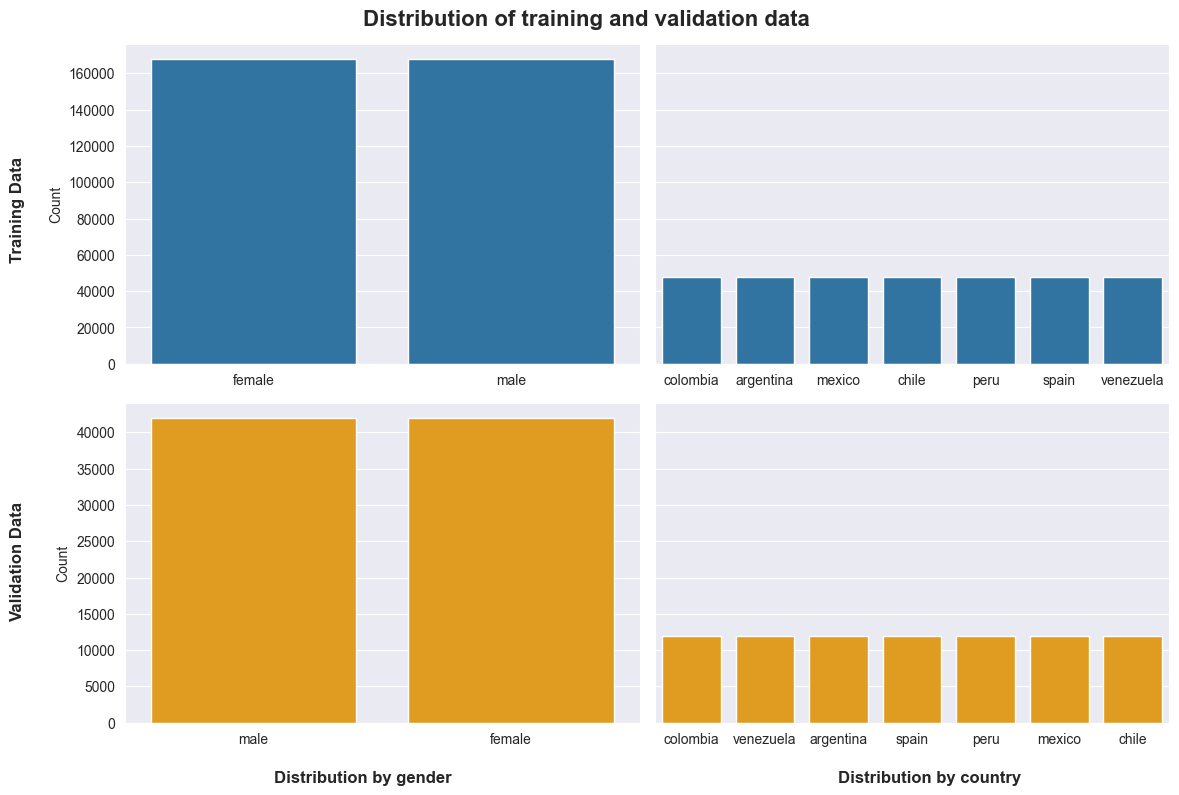

In [4]:
# Create a DataFrame for training and validation data.
df_train = pd.DataFrame(
    labels_train, columns = ["gender", "country"], index = range(1, len(labels_train) + 1))
df_val = pd.DataFrame(
    labels_val, columns = ["gender", "country"], index = range(1, len(labels_val) + 1))

# Graphs for training and validation data.
fig, axs = plt.subplots(2, 2, figsize = (12,8), sharey = 'row')
fig.suptitle('Distribution of training and validation data', fontsize = 16, weight = 'bold')

# Graphs for training data.
sns.countplot(data = df_train, x = "gender", ax = axs[0,0])
sns.countplot(data = df_train, x = "country", ax = axs[0,1])

# Graphs for validation data.
sns.countplot(data = df_val, x = "gender", ax = axs[1,0], color = "orange")
sns.countplot(data = df_val, x = "country", ax = axs[1,1], color = "orange")

# Set the title for each subplot.
for ax in axs.flatten():
    ax.set_xlabel("")
axs[0,0].set_ylabel("Count")
axs[0,1].set_ylabel("")
axs[1,0].set_ylabel("Count")
axs[1,1].set_ylabel("")

# Labels for the axes.
fig.text(0.71, 0.02, 'Distribution by country', va = 'center', rotation = 'horizontal', fontsize = 12, weight = 'bold')
fig.text(0.24, 0.02, 'Distribution by gender', va = 'center', rotation = 'horizontal', fontsize = 12, weight = 'bold')
fig.text(0.02, 0.73, 'Training Data', va = 'center', rotation = 'vertical', fontsize = 12, weight = 'bold')
fig.text(0.02, 0.29, 'Validation Data', va = 'center', rotation = 'vertical', fontsize = 12, weight = 'bold')

plt.tight_layout(rect = [0.04, 0.04, 1, 1])
plt.show()

In [5]:
class AuthorProfilingDataset(Dataset):
    def __init__(self, corpus: List[str], labels: List[int]):
        
        # Initialize the dataset.
        self.corpus = corpus
        self.labels = labels

        # Load the vocabulary and embeddings.
        self.vocab, self.emb_mat = AuthorProfilingDataset.load_vocab_embeddings()

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int, List[str]]:
        """
        Get the item at the specified index.

        Parameters
        ----------
        index : int
            The index of the item.

        Returns
        -------
        tuple
            A tuple containing the word ids, label, and words.
        """
        text = self.corpus[index]
        label = self.labels[index]
        words, word_ids = self.preprocessed_text(text)
        return word_ids, label, words

    def preprocessed_text(self, text: str) -> Tuple[List[str], List[int]]:
        """
        Preprocess the text.

        Parameters
        ----------
        text : str
            The text to be preprocessed.
        
        Returns
        -------
        tuple
            A tuple containing the words and word ids.
        """
        words = nltk.word_tokenize(text)
        word_ids = [self.vocab[word] if word in self.vocab.keys() else self.emb_mat.shape[0] - 1
                    for word in words]
        return words, word_ids
    
    @staticmethod
    def load_vocab_embeddings() -> Tuple[dict, np.ndarray]:
        """
        Load the vocabulary and pre-trained embeddings.

        Returns
        -------
        tuple
            A tuple containing the vocabulary and embeddings.
        """
        embeddings_list = []
        vocab = {}
        with open('word2vec_col.txt', 'r') as f:
            for i, line in enumerate(f):
                if i != 0:
                    values = line.split()
                    vocab[values[0]] = i + 1
                    vector = np.asarray(values[1:], dtype = "float32")
                    embeddings_list.append(vector)
        embeddings_list.insert(0, np.mean(np.vstack(embeddings_list), axis = 0)) # Mean vector for unk
        embeddings_list.insert(0, np.zeros(100))                                 # Padding vector
        vocab['pad'] = 0
        vocab['unk'] = 1
        emb_mat = np.vstack(embeddings_list)
        return vocab, emb_mat

    def get_weights(self) -> torch.Tensor:
        """
        Calculate class weights for imbalanced datasets. The higher weight the category has, the less samples it has.
        """
        cat_0 = self.labels.count(0)
        cat_1 = self.labels.count(1)
        maxi = max(cat_0, cat_1)
        return torch.tensor([maxi / cat_0, maxi / cat_1])

    @staticmethod
    def collate_fn(batch: List[Tuple[torch.Tensor, int, List[str]]]) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, List[str]]:
        """
        Create a batch from the data.

        Parameters
        ----------
        batch : list
            A list containing the data.
        
        Returns
        -------
        tuple
            A tuple containing the word ids, lengths, labels, and words.
        """
        zipped_batch = list(zip(*batch))
        word_ids = [torch.tensor(t) for t in zipped_batch[0]]
        word_ids = torch.nn.utils.rnn.pad_sequence(word_ids, batch_first=True, padding_value=0)
        lengths = torch.tensor([len(t) for t in zipped_batch[0]])
        labels = torch.tensor(zipped_batch[1])
        words = zipped_batch[2]
        return word_ids, lengths, labels, words

In [6]:
train_dataset = AuthorProfilingDataset(data_train, labels_train)
val_dataset = AuthorProfilingDataset(data_val, labels_val)

# **2.- (40pts) Diseñe un clasificador con alguna RNN con atención en jerárquia (como en el paper adjunto) que codifique cada perfil de usuario con todos sus tweets y clasifique. El primer nivel intuitivamente recibe embeddings de palabras, el segundo nivel de atención modela los tweets. Preinicialice su red con los embeedings w2v proporcionados.**

# **5.- (30pts) Discuta brevemente el rendimiento del modelo anterior. Para el punto anterior, construya algunas visualizaciones como en la Figura 6 del paper de atención jerárquica y discuta.**

# **6.- (20pts) Conteste lo siguiente MUY brevemente:**

### **6.1.- ¿Qué representación de términos uso el profesor para participar? http://ceur-ws.org/Vol-1866/paper_109.pdf**

### **6.2.- ¿Qué usó el primer lugar de la competencia? (Basile, et al.) (Consulte: http://ceur-ws.org/Vol-1866/)**

### **6.3.- ¿Cuántos y que competidores usaron deep learning? En una o dos oraciones escriba qué hicieron: https://ceur-ws.org/Vol-1866/**

# **7.- (10pts) extra (Máxima Calificación 110%) para esta tarea: haga una comparación que muestre si la atención en jerarquía es util vs no tenerla (e.g., sin atención o tener un solo nivel de atención)**